# Notes
## NUTS/MCMC
- "No U-Turns" algorithm/variant of MCMC, considered state of the art
- g2 formula unchanged, but loss model includes an extra parameter for noise stdev, used to calculate log-likelihood
- MCMC uses the likelihood and _priors_ to run some sort of Metropolic-Hasting based method to "sample" the eventual stable distribution corresponding to our fitting parameters
- fits under the general class of Bayesian Inference/Optimization
- uninformative vs informative priors - "eliciting a prior"
    - __we can pre condition this with our trust region gradient based optimization__
- for now, used some fixed, uninformed priors
- using numpyro as the MCMC framework and arviz for exploratory vizualizations made for Bayesian methods. numpyro has weird style
- handles simple additive gaussian noise OKish - gets closer with smaller noise, which our method has struggled with
- run with multiple independent chains (monte carlo aspect) and they should generally agree
- interesting behavior for one of the problems:
    - run with 4 chains for two-source model
    - 2 chains find true parameters
    - 2 chains push amplitude of one source to 1 and basically do a one-source fit with that source

- bumping up num devices available to numpyro does seem to speed up computation (2 helps, 4 might not do more, check environment/profile)



## einsum quadrature
- Laguerre Quadrature doesn't change optimization
- einsums implementation probably not desirable - bad readability and vmap kernel fusion probably faster _should test this test_ 
- __TODO__ add math for quadrature into quadrature nb


In [1]:
import jax
jax.config.update("jax_enable_x64", True)  # Enable 64-bit precision
jax.config.update("jax_platforms", "cpu")
import jax.numpy as jnp
import numpyro
numpyro.set_host_device_count(4)
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import orthax
import functools
import pandas as pd

# --- User's Original Model Code (Copied Verbatim) ---
# This section contains the multiangle DLS model you provided.
# It has been copied without any modifications.

# quadrature based model

SCALING_CONST = 2.45e-12
relative_scaling = 1.3e-14 / SCALING_CONST

# calculate normal curve values
def normal_distribution_single(x, amplitude, mu, sigma):
    return amplitude * jnp.exp(-(x-mu)**2/(2*sigma**2))/jnp.sqrt(2*jnp.pi*sigma**2)

normal_distributions = jax.vmap(normal_distribution_single, in_axes=(None, 0, 0, 0))

def normal_distribution(possible_D, amp, mu, sig):
    whole = normal_distributions(possible_D, amp, mu, sig).sum(axis=0)
    return whole / jnp.sum(whole) # normalize for plotting

def g2_minus1_quadrature_einsum(q, t, amp, mu, sig, beta, scaling_const, laguerre_deg):
    t_ = SCALING_CONST*t
    x_lag, w_lag = orthax.laguerre.laggauss(laguerre_deg)
    quad_lag = w_lag * normal_distributions(x_lag*scaling_const, amp, mu, sig)
    q2t = jnp.einsum("q,t->qt", q**2, t_)
    exp_term = jnp.exp(jnp.einsum("qt,l->qtl", 1-scaling_const*q2t, x_lag))
    g1 = scaling_const * jnp.einsum("qtl,kl->qt", exp_term, quad_lag)
    return beta*jnp.square(g1)

g2_minus1_quadrature_scaled = jax.jit(functools.partial(
    g2_minus1_quadrature_einsum,
    # scaling_const=SCALING_CONST*5e-2,
    scaling_const=relative_scaling,
    laguerre_deg = 100
))


ERROR:2025-08-26 13:44:16,787:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 100; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


In [2]:
def scatter_vector(theta, lambda_0=633e-9, n=1.33, radians=False):
    """
    theta - scatter angle
    lambda_0 - lsder wavelength in meters
    n - refractive index of water
    """
    if not radians:
        theta = jnp.radians(theta)
    return (4 * jnp.pi * n/lambda_0) * jnp.sin(theta / 2)

def diffusion_coef(r, k_B=1.38e-23, T=298.15, eta=0.00089):
    """
    r - particle radius
    k_b - Boltzmann constant (J/K)
    T - Temperature (K)
    eta - Viscosity of water at room temerature (Pa*s)
    """
    return k_B * T / (6 * jnp.pi * eta * r)

def normal_to_lognormal_params(mu, sigma):
    sigma_ln_sq = jnp.log(1 + (sigma / mu)**2)
    mu_ln = jnp.log(mu) - (sigma_ln_sq / 2)
    sigma_ln = jnp.sqrt(sigma_ln_sq)
    return (mu_ln, sigma_ln)

def prep_data(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s

    # observation data is g2(t) - 1
    g2_minus1_obs = d[:, 1:].T

    div = jax.vmap(lambda x: x/x[0])
    g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    # g1 = jnp.sqrt(jnp.maximum(g1_squared, 0)) # this line converts to g1

    g1 = jnp.where(
        jnp.greater_equal(g1_squared, 0),
        jnp.sqrt(g1_squared),
        -jnp.sqrt(-g1_squared)
    )

    # g1 = jnp.sign(g1_squared) * jnp.sqrt(jnp.abs(g1_squared))

    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    return q, t, g1

def prep_data_g2(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s

    # observation data is g2(t) - 1
    g2_minus1_obs = d[:, 1:].T

    div = jax.vmap(lambda x: x/x[0])
    g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    # # g1 = jnp.sqrt(jnp.maximum(g1_squared, 0)) # this line converts to g1
    # g1 = jnp.where(
    #     jnp.greater_equal(g1_squared, 0),
    #     jnp.sqrt(g1_squared),
    #     -jnp.sqrt(-g1_squared)
    # )

    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    # return q, t, g2_minus1_obs
    return q, t, g1_squared



In [3]:
# @jax.jit
def dls_model2(q, t, preconditioned_priors, g2_obs=None):
    beta = numpyro.sample("beta", dist.Beta(7, 3))

    # Amplitudes of the Gaussian components must sum to 1.
    amp = numpyro.sample("amp", dist.Dirichlet(preconditioned_priors['amp']))

    # --- Tighter, Ordered Priors for mu to prevent instability and label switching ---
    # We sample the first component (mu0), and the second as a positive increment (mu_inc)
    # from the first. This enforces mu[1] > mu[0] and makes the model identifiable.
    # The priors are also tighter (scale=0.2) to guide the sampler away from extreme values.

    mu_prior, sig_prior = normal_to_lognormal_params(preconditioned_priors['mu'], preconditioned_priors['sig'])
    order = jnp.argsort(mu_prior)
    mu = numpyro.sample("mu", dist.LogNormal(mu_prior[order], sig_prior[order]*2))
    # numpyro.deterministic("mu", mu)

    # # Center the increment around the expected difference from the true parameters
    # mu_inc_loc = jnp.log(mu_prior.max() - mu_prior.min())
    # mu_inc = numpyro.sample("mu_inc", dist.LogNormal(mu_inc_loc, 0.2))

    # # Combine into the final mu array
    # mu = jnp.array([mu0, mu0 + mu_inc])
    # # Use deterministic to save the combined 'mu' in the trace for easy analysis
    # numpyro.deterministic("mu", mu)

    # --- Tighter Priors for sig ---
    # We use a tighter scale (0.2) to avoid extremely small or large values
    # that cause the a = mu/sig ratio to explode.
    # sig_loc = jnp.log(jnp.array([0.65, 0.65]))
    sig = numpyro.sample("sig", dist.LogNormal(sig_prior[order]/2, 0.2))

    mse = preconditioned_priors['loss']
    # Observational noise must be positive.
    noise_std = numpyro.sample("noise_std", dist.HalfNormal(mse))

    # --- Deterministic Model Prediction ---
    # g2_predicted = g2_minus1_matrix(q, t, amp, mu, sig, beta)
    g2_predicted = g2_minus1_quadrature_scaled(q, t, amp, mu, sig, beta)

    # --- Likelihood Function ---
    numpyro.sample("obs", dist.Normal(g2_predicted, noise_std), obs=g2_obs)

In [4]:
## generate data 

rng_key = jax.random.PRNGKey(42)
rng_key, model_key, data_key = jax.random.split(rng_key, 3)
q_vals, t_vals, observations100_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_100nm.csv")
q_vals, t_vals, observations200_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_200nm.csv")
q_vals, t_vals, observations500_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_500nm.csv")
q_vals, t_vals, observations1000_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_1000nm.csv")
q_vals, t_vals, mix_1_g2 = prep_data_g2("~/repos/DLS/Experimental_data_083122/mix_1.csv")


# observed_g2 = mix_1_g2


# True parameters for generating synthetic data
true_params = {
    'beta': 1.0,
    'amp': jnp.array([0.8, 0.2]),
    'mu': jnp.array([0.7, 0.1]),
    'sig': jnp.array([0.14, 0.03]),
    'loss': 0.01,
    'noise_std': 0.001
}

true_g2 = g2_minus1_quadrature_scaled(
    q_vals, t_vals,
    true_params['amp'], true_params['mu'], true_params['sig'], true_params['beta']
)
observed_g2 = true_g2 + true_params['noise_std'] * jax.random.normal(data_key, shape=true_g2.shape)



In [ ]:
# 3. Set up and run the MCMC sampler

preconditioned_priors = {
    'beta': 1.0,
    'amp': jnp.array([0.5, 0.5]),
    'mu': jnp.array([1.1, 1.4]),
    'sig': jnp.array([0.3, 0.4]),
    'loss': 0.01
}

kernel = NUTS(dls_model2, target_accept_prob=0.8)
mcmc = MCMC(
    kernel,
    num_warmup=500,
    num_samples=1000,
    num_chains=4,
    progress_bar=True,
    jit_model_args=True,
)
print("Running MCMC with robust, ordered priors...")
mcmc.run(rng_key, q=q_vals, t=t_vals, g2_obs=observed_g2, preconditioned_priors=preconditioned_priors)
print("MCMC complete.")

# 4. Print the summary of the posterior distributions
mcmc.print_summary()


Running MCMC with robust, ordered priors...


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

MCMC complete.

                 mean       std    median      5.0%     95.0%     n_eff     r_hat
     amp[0]      0.40      0.40      0.39      0.00      0.80      2.00    159.55
     amp[1]      0.60      0.40      0.61      0.20      1.00      2.00    159.55
       beta      1.00      0.00      1.00      1.00      1.00      7.57      1.17
      mu[0]      0.94      0.50      0.70      0.44      1.71      8.15      1.16
      mu[1]      0.33      0.23      0.33      0.10      0.55      2.00    157.48
  noise_std      0.00      0.00      0.00      0.00      0.01      2.00     55.27
     sig[0]      0.64      0.53      0.34      0.12      1.32      2.16      3.52
     sig[1]      0.11      0.08      0.11      0.03      0.19      2.00    114.29

Number of divergences: 0


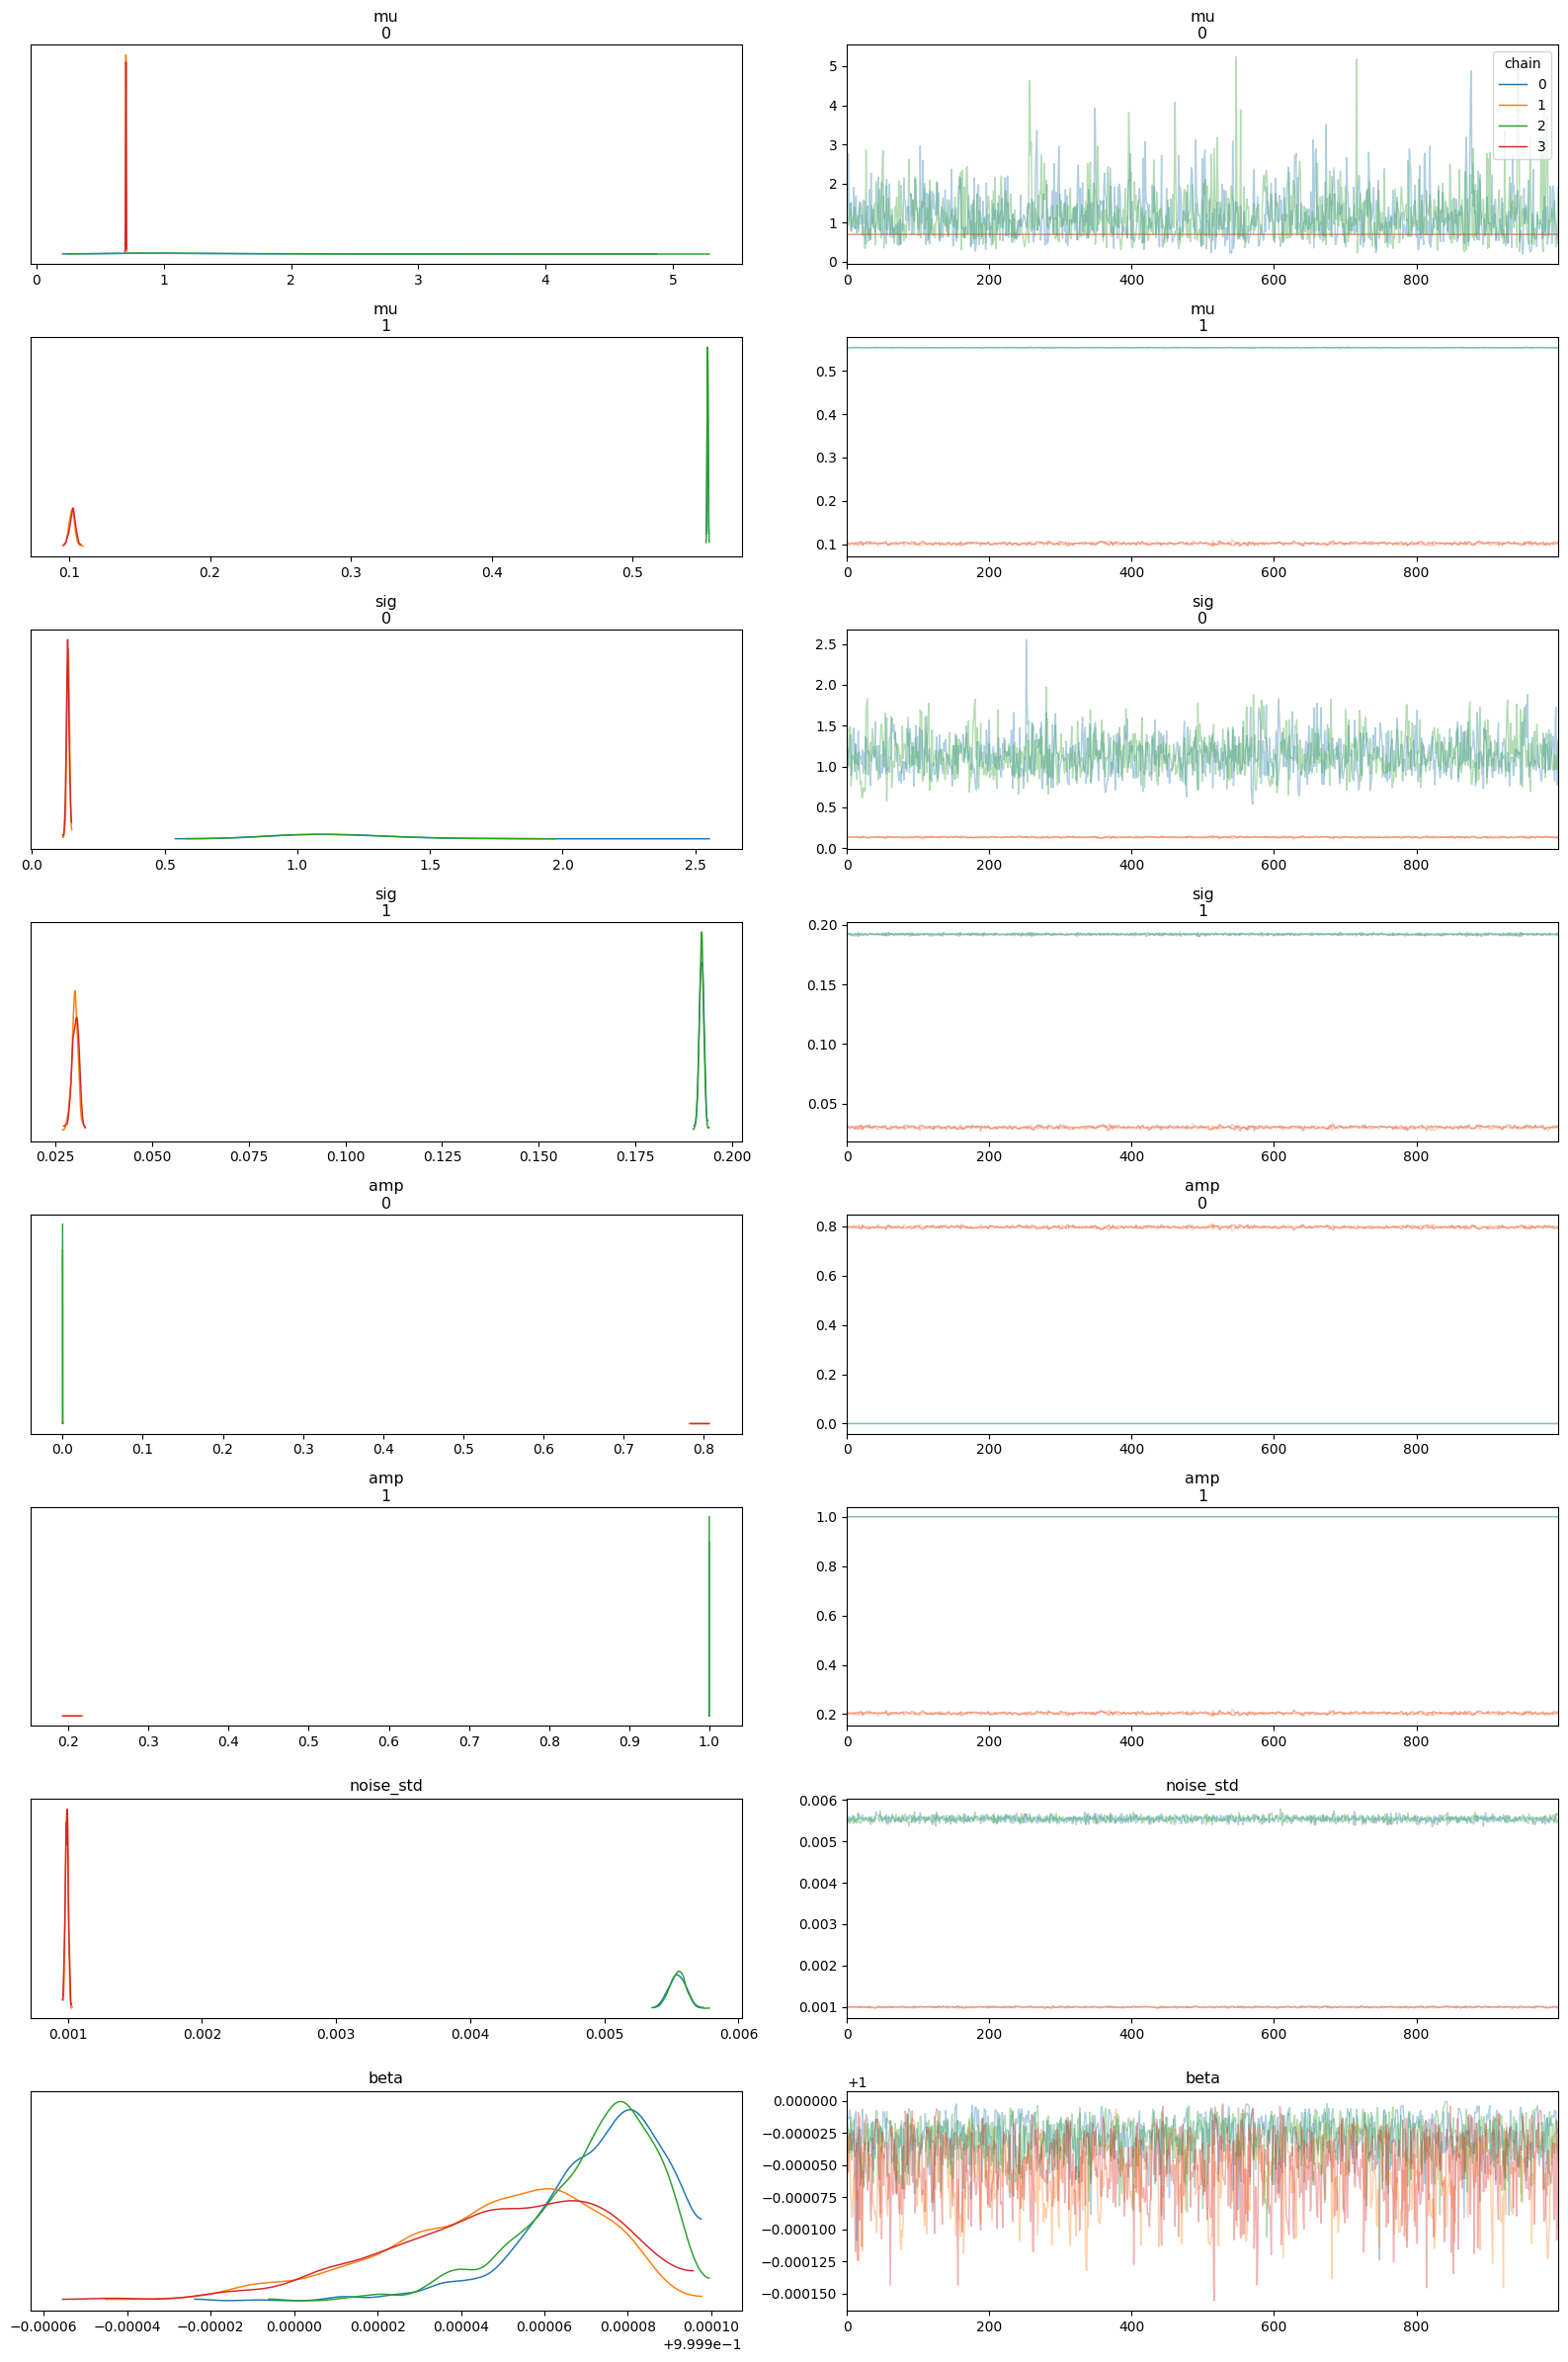


Running posterior predictive checks...


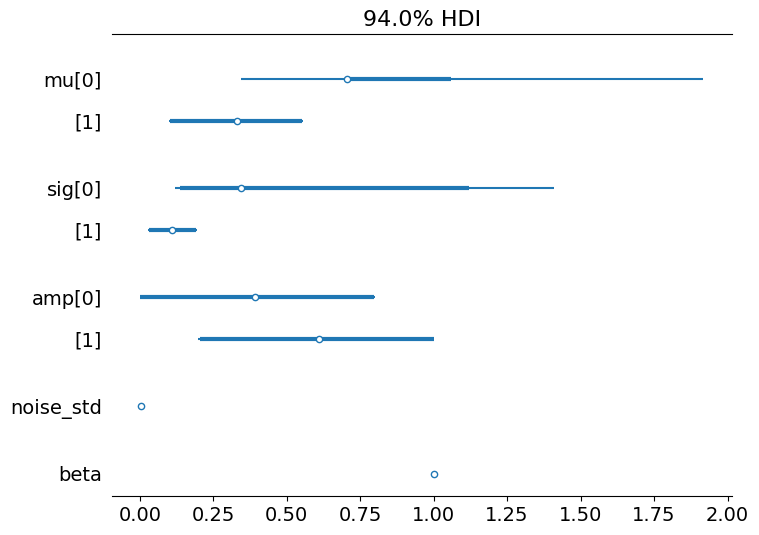

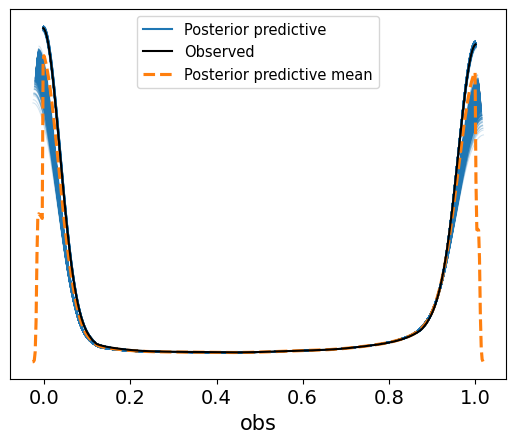

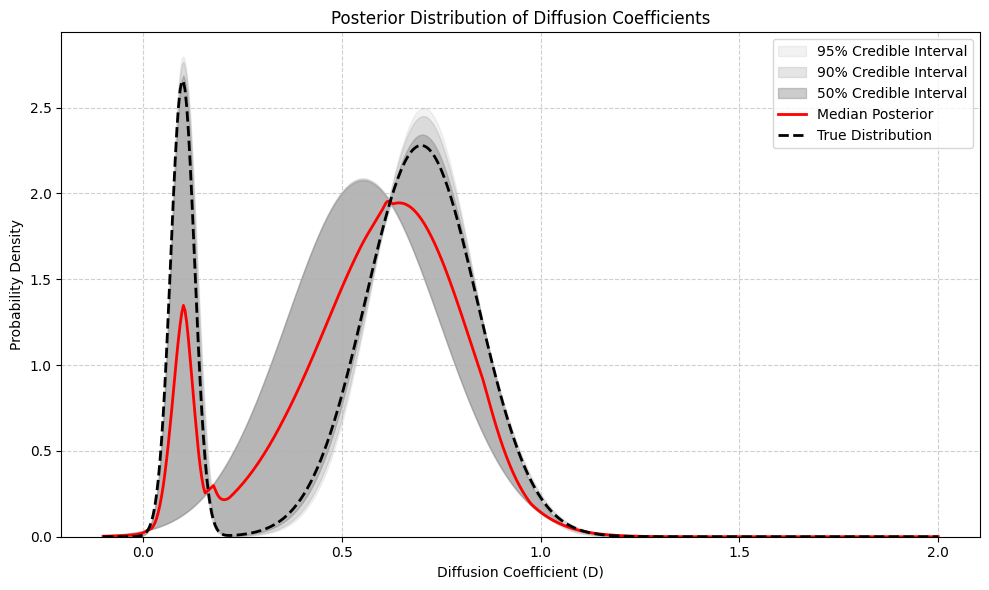

In [11]:
# --- Visualize the results with ArviZ ---
# This is still useful for diagnosing the individual parameters
# print("\nGenerating ArviZ plots...")
idata = az.from_numpyro(mcmc)
az.plot_trace(idata, var_names=["mu", "sig", "amp", "noise_std", "beta"], legend=True, figsize=(16, 24), compact=False)
plt.tight_layout()
plt.show()

az.plot_forest(idata, var_names=["mu", "sig", "amp", "noise_std", "beta"], combined=True, figsize=(8, 6))

from numpyro.infer import Predictive

# ... after mcmc.run(...)

print("\nRunning posterior predictive checks...")
# Create a predictive model that samples new data based on the posterior
posterior_predictive = Predictive(dls_model2, mcmc.get_samples())
# Generate new data sets
posterior_predictions = posterior_predictive(rng_key, q=q_vals, t=t_vals, preconditioned_priors=preconditioned_priors)

# Use ArviZ to plot the results
az.plot_ppc(az.from_numpyro(mcmc, posterior_predictive=posterior_predictions))
plt.show()


# 5. Get posterior samples
posterior_samples = mcmc.get_samples()
amps = posterior_samples['amp']
mus = posterior_samples['mu']
sigs = posterior_samples['sig']
# sigs = true_params['sig']

# 6. Define a helper function for a Gaussian PDF
def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# 7. Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))
D_range = np.linspace(-0.1, 2, 500) # Range of diffusion coefficients

# 8. Calculate all posterior PDFs and store them in a matrix
num_samples = amps.shape[0]
num_components = amps.shape[1]
all_pdfs = np.zeros((num_samples, len(D_range)))

for i in range(num_samples):
    for j in range(num_components):
        all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[i, j])
        # all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[j])
        
# 9. Calculate quantiles to define the credible intervals
# We'll calculate the 90% interval (5th to 95th percentile) and
# the 50% interval (25th to 75th percentile).
q2, q5, q25, q50, q75, q95, q98 = np.quantile(all_pdfs, [0.02, 0.05, 0.25, 0.5, 0.75, 0.95, 0.98], axis=0)

ax.fill_between(D_range, q2, q98, color='gray', alpha=0.1, label='95% Credible Interval')
# 10. Plot the credible interval bands
# The wider, more transparent band (90% CI)
ax.fill_between(D_range, q5, q95, color='gray', alpha=0.2, label='90% Credible Interval')
# The narrower, darker band (50% CI)
ax.fill_between(D_range, q25, q75, color='gray', alpha=0.4, label='50% Credible Interval')

# 11. Plot the median posterior distribution
# The median (50th percentile) is often more robust than the mean.
ax.plot(D_range, q50, color='red', lw=2, label='Median Posterior')

# 12. Plot the true distribution for comparison
true_mixture_pdf = np.zeros_like(D_range)
for j in range(true_params['amp'].shape[0]):
    true_mixture_pdf += true_params['amp'][j] * gaussian(D_range, true_params['mu'][j], true_params['sig'][j])
ax.plot(D_range, true_mixture_pdf, color='black', ls='--', lw=2, label='True Distribution')

# 13. Finalize the plot
ax.set_xlabel('Diffusion Coefficient (D)')
ax.set_ylabel('Probability Density')
ax.set_title('Posterior Distribution of Diffusion Coefficients')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()



/home/gfertt/.local/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu0'] have not been found and will be ignored
  warnings.warn(


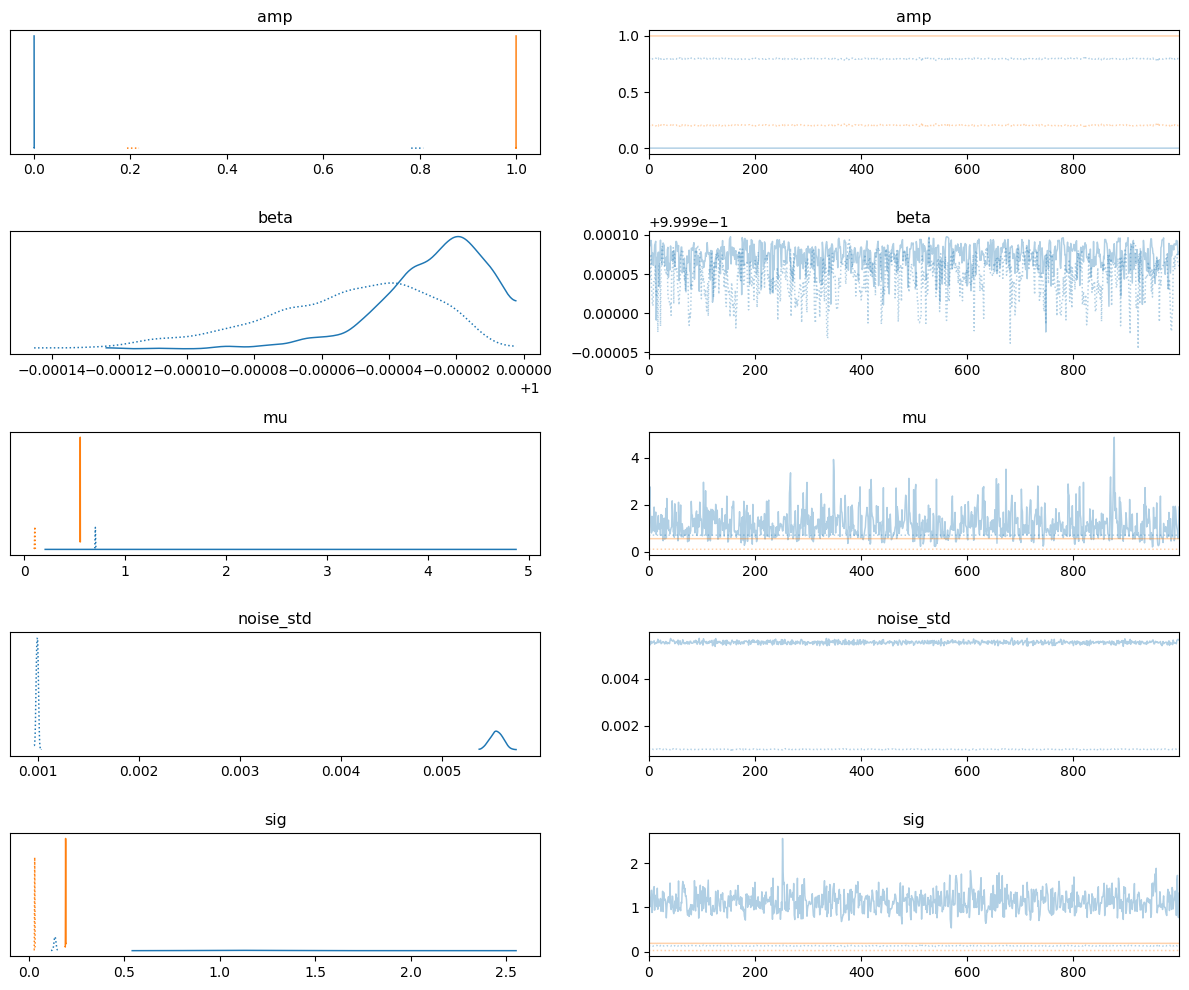


Running posterior predictive checks...


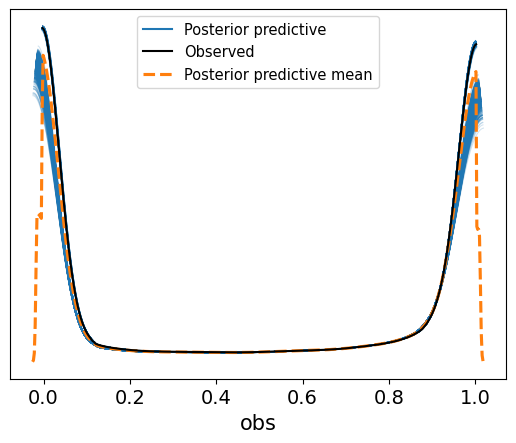

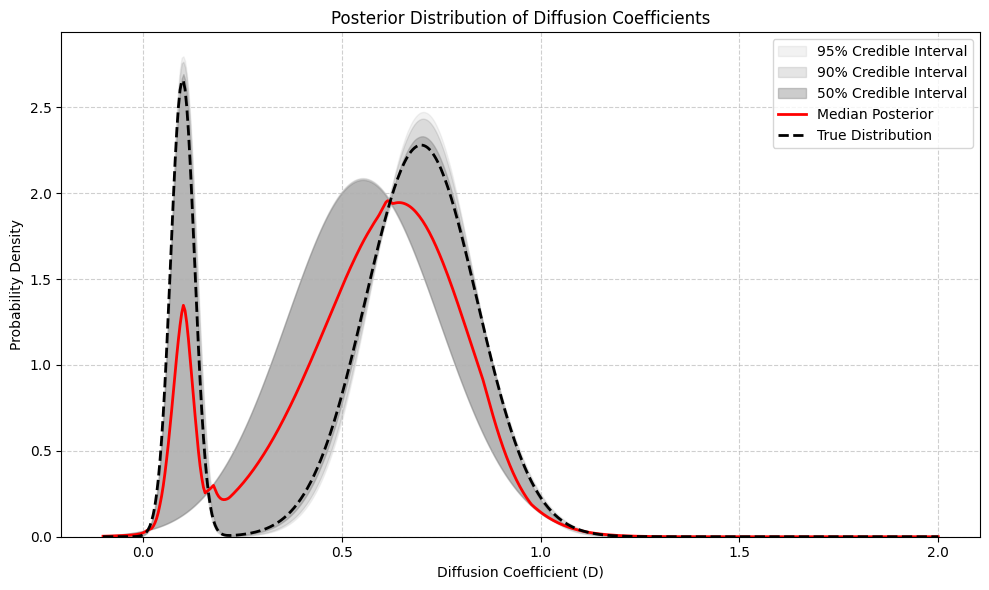

In [19]:
# --- Visualize the results with ArviZ ---
# This is still useful for diagnosing the individual parameters
# print("\nGenerating ArviZ plots...")
idata = az.from_numpyro(mcmc)
az.plot_trace(idata, var_names=["~mu0"])
plt.tight_layout()
plt.show()

from numpyro.infer import Predictive

# ... after mcmc.run(...)

print("\nRunning posterior predictive checks...")
# Create a predictive model that samples new data based on the posterior
posterior_predictive = Predictive(dls_model2, mcmc.get_samples())
# Generate new data sets
posterior_predictions = posterior_predictive(rng_key, q=q_vals, t=t_vals, preconditioned_priors=preconditioned_priors)

# Use ArviZ to plot the results
az.plot_ppc(az.from_numpyro(mcmc, posterior_predictive=posterior_predictions))
plt.show()


# 5. Get posterior samples
posterior_samples = mcmc.get_samples()
amps = posterior_samples['amp']
mus = posterior_samples['mu']
sigs = posterior_samples['sig']
# sigs = true_params['sig']

# 6. Define a helper function for a Gaussian PDF
def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# 7. Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))
D_range = np.linspace(-0.1, 2, 500) # Range of diffusion coefficients

# 8. Calculate all posterior PDFs and store them in a matrix
num_samples = amps.shape[0]
num_components = amps.shape[1]
all_pdfs = np.zeros((num_samples, len(D_range)))

for i in range(num_samples):
    for j in range(num_components):
        all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[i, j])
        # all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[j])
        
# 9. Calculate quantiles to define the credible intervals
# We'll calculate the 90% interval (5th to 95th percentile) and
# the 50% interval (25th to 75th percentile).
q2, q5, q25, q50, q75, q95, q98 = np.quantile(all_pdfs, [0.02, 0.05, 0.25, 0.5, 0.75, 0.95, 0.98], axis=0)

ax.fill_between(D_range, q2, q98, color='gray', alpha=0.1, label='95% Credible Interval')
# 10. Plot the credible interval bands
# The wider, more transparent band (90% CI)
ax.fill_between(D_range, q5, q95, color='gray', alpha=0.2, label='90% Credible Interval')
# The narrower, darker band (50% CI)
ax.fill_between(D_range, q25, q75, color='gray', alpha=0.4, label='50% Credible Interval')

# 11. Plot the median posterior distribution
# The median (50th percentile) is often more robust than the mean.
ax.plot(D_range, q50, color='red', lw=2, label='Median Posterior')

# 12. Plot the true distribution for comparison
true_mixture_pdf = np.zeros_like(D_range)
for j in range(true_params['amp'].shape[0]):
    true_mixture_pdf += true_params['amp'][j] * gaussian(D_range, true_params['mu'][j], true_params['sig'][j])
ax.plot(D_range, true_mixture_pdf, color='black', ls='--', lw=2, label='True Distribution')

# 13. Finalize the plot
ax.set_xlabel('Diffusion Coefficient (D)')
ax.set_ylabel('Probability Density')
ax.set_title('Posterior Distribution of Diffusion Coefficients')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()



/home/gfertt/.local/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu0'] have not been found and will be ignored
  warnings.warn(


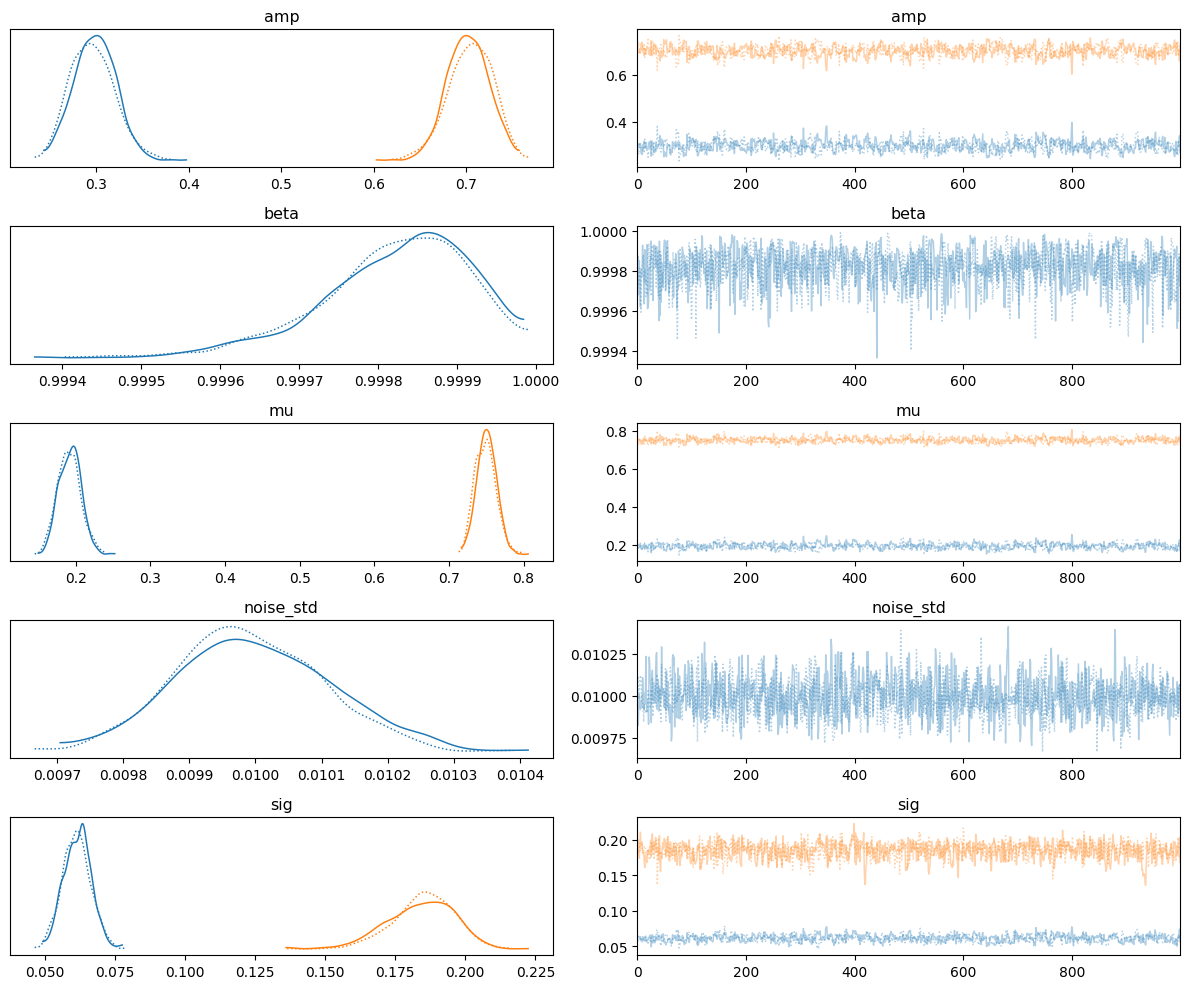


Running posterior predictive checks...


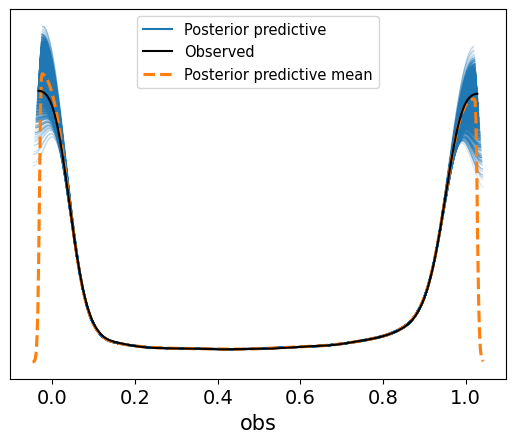

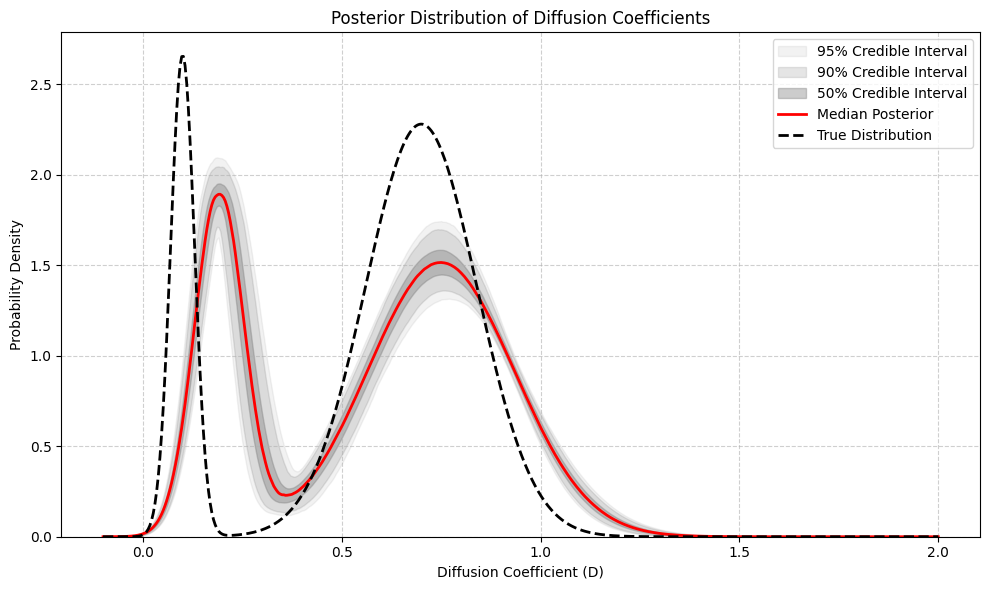

In [14]:
# --- Visualize the results with ArviZ ---
# This is still useful for diagnosing the individual parameters
# print("\nGenerating ArviZ plots...")
idata = az.from_numpyro(mcmc)
az.plot_trace(idata, var_names=["~mu0"])
plt.tight_layout()
plt.show()

from numpyro.infer import Predictive

# ... after mcmc.run(...)

print("\nRunning posterior predictive checks...")
# Create a predictive model that samples new data based on the posterior
posterior_predictive = Predictive(dls_model2, mcmc.get_samples())
# Generate new data sets
posterior_predictions = posterior_predictive(rng_key, q=q_vals, t=t_vals, preconditioned_priors=preconditioned_priors)

# Use ArviZ to plot the results
az.plot_ppc(az.from_numpyro(mcmc, posterior_predictive=posterior_predictions))
plt.show()


# 5. Get posterior samples
posterior_samples = mcmc.get_samples()
amps = posterior_samples['amp']
mus = posterior_samples['mu']
sigs = posterior_samples['sig']
# sigs = true_params['sig']

# 6. Define a helper function for a Gaussian PDF
def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# 7. Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))
D_range = np.linspace(-0.1, 2, 500) # Range of diffusion coefficients

# 8. Calculate all posterior PDFs and store them in a matrix
num_samples = amps.shape[0]
num_components = amps.shape[1]
all_pdfs = np.zeros((num_samples, len(D_range)))

for i in range(num_samples):
    for j in range(num_components):
        all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[i, j])
        # all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[j])
        
# 9. Calculate quantiles to define the credible intervals
# We'll calculate the 90% interval (5th to 95th percentile) and
# the 50% interval (25th to 75th percentile).
q2, q5, q25, q50, q75, q95, q98 = np.quantile(all_pdfs, [0.02, 0.05, 0.25, 0.5, 0.75, 0.95, 0.98], axis=0)

ax.fill_between(D_range, q2, q98, color='gray', alpha=0.1, label='95% Credible Interval')
# 10. Plot the credible interval bands
# The wider, more transparent band (90% CI)
ax.fill_between(D_range, q5, q95, color='gray', alpha=0.2, label='90% Credible Interval')
# The narrower, darker band (50% CI)
ax.fill_between(D_range, q25, q75, color='gray', alpha=0.4, label='50% Credible Interval')

# 11. Plot the median posterior distribution
# The median (50th percentile) is often more robust than the mean.
ax.plot(D_range, q50, color='red', lw=2, label='Median Posterior')

# 12. Plot the true distribution for comparison
true_mixture_pdf = np.zeros_like(D_range)
for j in range(true_params['amp'].shape[0]):
    true_mixture_pdf += true_params['amp'][j] * gaussian(D_range, true_params['mu'][j], true_params['sig'][j])
ax.plot(D_range, true_mixture_pdf, color='black', ls='--', lw=2, label='True Distribution')

# 13. Finalize the plot
ax.set_xlabel('Diffusion Coefficient (D)')
ax.set_ylabel('Probability Density')
ax.set_title('Posterior Distribution of Diffusion Coefficients')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()



/home/gfertt/.local/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu0'] have not been found and will be ignored
  warnings.warn(


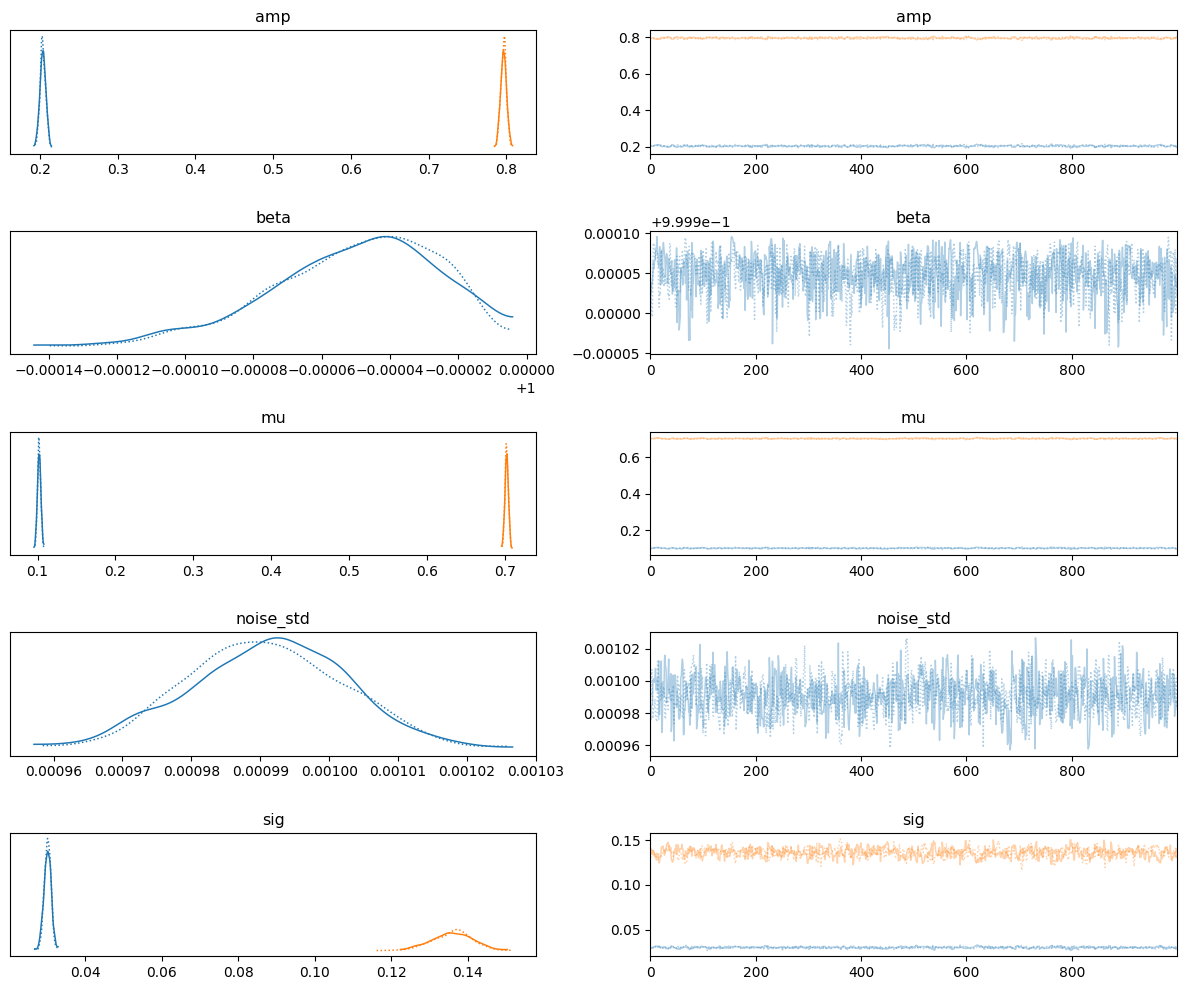


Running posterior predictive checks...


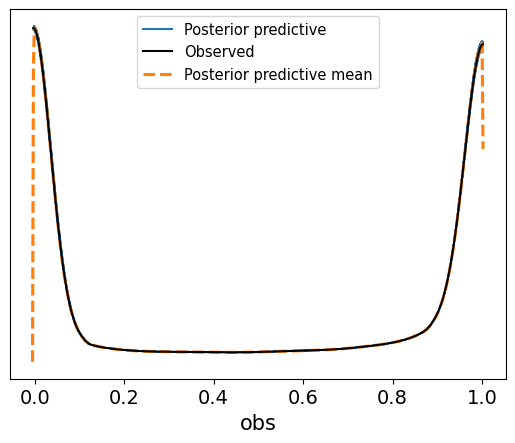

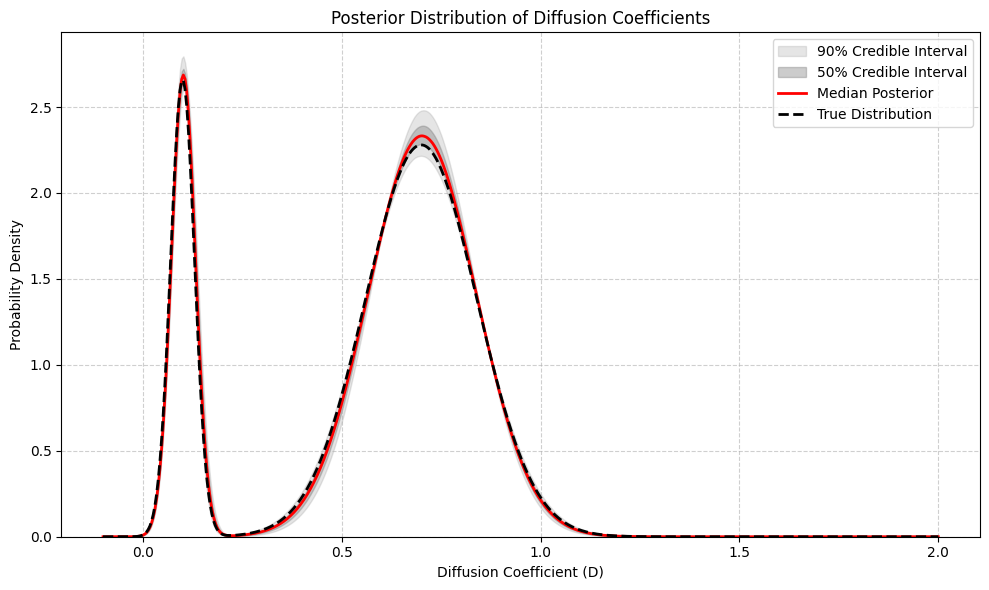

In [9]:
# --- Visualize the results with ArviZ ---
# This is still useful for diagnosing the individual parameters
# print("\nGenerating ArviZ plots...")
idata = az.from_numpyro(mcmc)
az.plot_trace(idata, var_names=["~mu0"])
plt.tight_layout()
plt.show()

from numpyro.infer import Predictive

# ... after mcmc.run(...)

print("\nRunning posterior predictive checks...")
# Create a predictive model that samples new data based on the posterior
posterior_predictive = Predictive(dls_model2, mcmc.get_samples())
# Generate new data sets
posterior_predictions = posterior_predictive(rng_key, q=q_vals, t=t_vals, preconditioned_priors=preconditioned_priors)

# Use ArviZ to plot the results
az.plot_ppc(az.from_numpyro(mcmc, posterior_predictive=posterior_predictions))
plt.show()


# 5. Get posterior samples
posterior_samples = mcmc.get_samples()
amps = posterior_samples['amp']
mus = posterior_samples['mu']
sigs = posterior_samples['sig']
# sigs = true_params['sig']

# 6. Define a helper function for a Gaussian PDF
def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# 7. Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))
D_range = np.linspace(-0.1, 2, 500) # Range of diffusion coefficients

# 8. Calculate all posterior PDFs and store them in a matrix
num_samples = amps.shape[0]
num_components = amps.shape[1]
all_pdfs = np.zeros((num_samples, len(D_range)))

for i in range(num_samples):
    for j in range(num_components):
        all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[i, j])
        # all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[j])
        
# 9. Calculate quantiles to define the credible intervals
# We'll calculate the 90% interval (5th to 95th percentile) and
# the 50% interval (25th to 75th percentile).
q5, q25, q50, q75, q95 = np.quantile(all_pdfs, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)

# 10. Plot the credible interval bands
# The wider, more transparent band (90% CI)
ax.fill_between(D_range, q5, q95, color='gray', alpha=0.2, label='90% Credible Interval')
# The narrower, darker band (50% CI)
ax.fill_between(D_range, q25, q75, color='gray', alpha=0.4, label='50% Credible Interval')

# 11. Plot the median posterior distribution
# The median (50th percentile) is often more robust than the mean.
ax.plot(D_range, q50, color='red', lw=2, label='Median Posterior')

# 12. Plot the true distribution for comparison
true_mixture_pdf = np.zeros_like(D_range)
for j in range(true_params['amp'].shape[0]):
    true_mixture_pdf += true_params['amp'][j] * gaussian(D_range, true_params['mu'][j], true_params['sig'][j])
ax.plot(D_range, true_mixture_pdf, color='black', ls='--', lw=2, label='True Distribution')

# 13. Finalize the plot
ax.set_xlabel('Diffusion Coefficient (D)')
ax.set_ylabel('Probability Density')
ax.set_title('Posterior Distribution of Diffusion Coefficients')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()



/home/gfertt/.local/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu0'] have not been found and will be ignored
  warnings.warn(


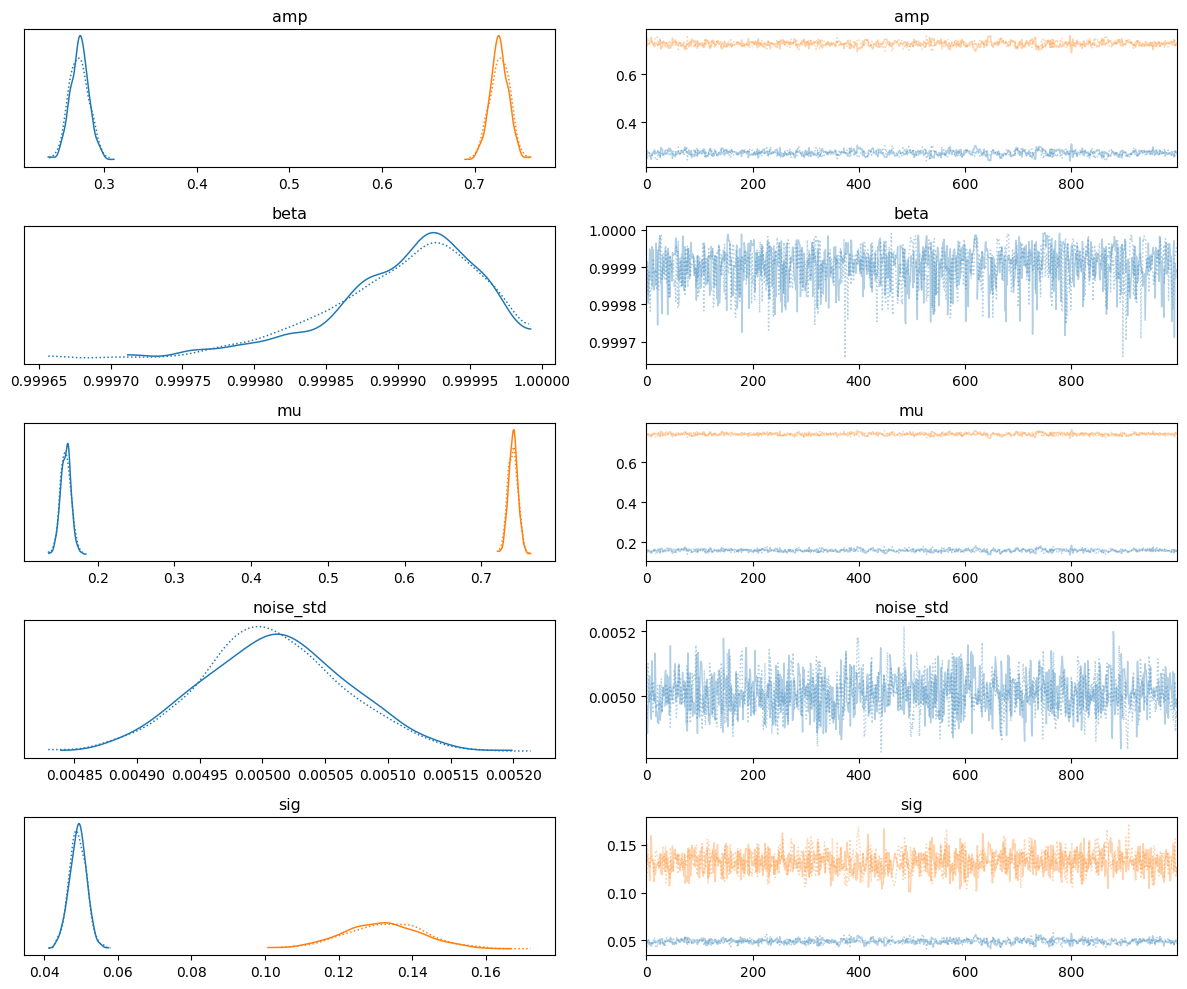

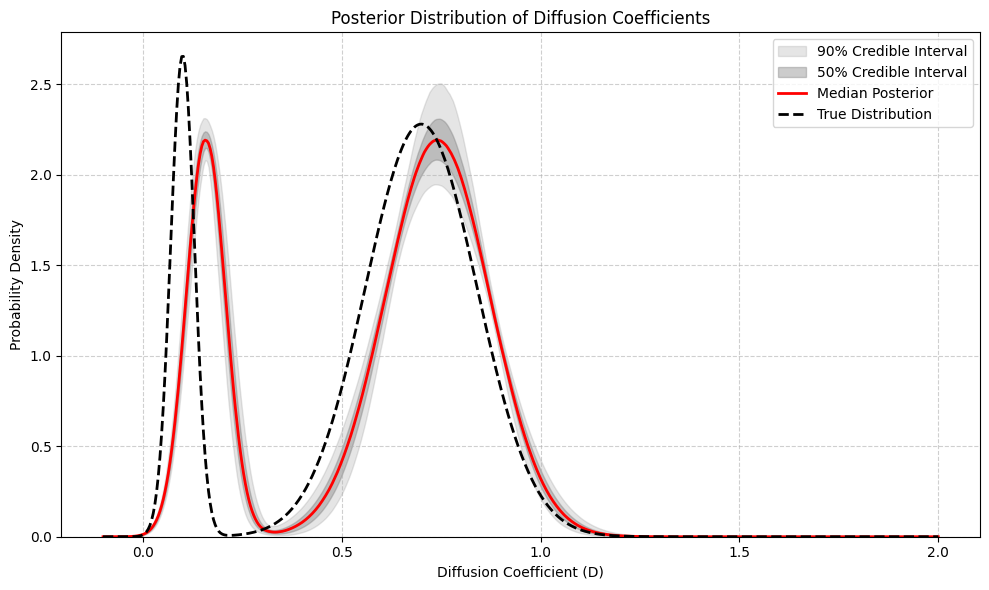

In [8]:
# --- Visualize the results with ArviZ ---
# This is still useful for diagnosing the individual parameters
# print("\nGenerating ArviZ plots...")
idata = az.from_numpyro(mcmc)
az.plot_trace(idata, var_names=["~mu0"])
plt.tight_layout()
plt.show()

# 5. Get posterior samples
posterior_samples = mcmc.get_samples()
amps = posterior_samples['amp']
mus = posterior_samples['mu']
sigs = posterior_samples['sig']
# sigs = true_params['sig']

# 6. Define a helper function for a Gaussian PDF
def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# 7. Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))
D_range = np.linspace(-0.1, 2, 500) # Range of diffusion coefficients

# 8. Calculate all posterior PDFs and store them in a matrix
num_samples = amps.shape[0]
num_components = amps.shape[1]
all_pdfs = np.zeros((num_samples, len(D_range)))

for i in range(num_samples):
    for j in range(num_components):
        all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[i, j])
        # all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[j])
        
# 9. Calculate quantiles to define the credible intervals
# We'll calculate the 90% interval (5th to 95th percentile) and
# the 50% interval (25th to 75th percentile).
q5, q25, q50, q75, q95 = np.quantile(all_pdfs, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)

# 10. Plot the credible interval bands
# The wider, more transparent band (90% CI)
ax.fill_between(D_range, q5, q95, color='gray', alpha=0.2, label='90% Credible Interval')
# The narrower, darker band (50% CI)
ax.fill_between(D_range, q25, q75, color='gray', alpha=0.4, label='50% Credible Interval')

# 11. Plot the median posterior distribution
# The median (50th percentile) is often more robust than the mean.
ax.plot(D_range, q50, color='red', lw=2, label='Median Posterior')

# 12. Plot the true distribution for comparison
true_mixture_pdf = np.zeros_like(D_range)
for j in range(true_params['amp'].shape[0]):
    true_mixture_pdf += true_params['amp'][j] * gaussian(D_range, true_params['mu'][j], true_params['sig'][j])
ax.plot(D_range, true_mixture_pdf, color='black', ls='--', lw=2, label='True Distribution')

# 13. Finalize the plot
ax.set_xlabel('Diffusion Coefficient (D)')
ax.set_ylabel('Probability Density')
ax.set_title('Posterior Distribution of Diffusion Coefficients')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()



/home/gfertt/.local/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu0'] have not been found and will be ignored
  warnings.warn(


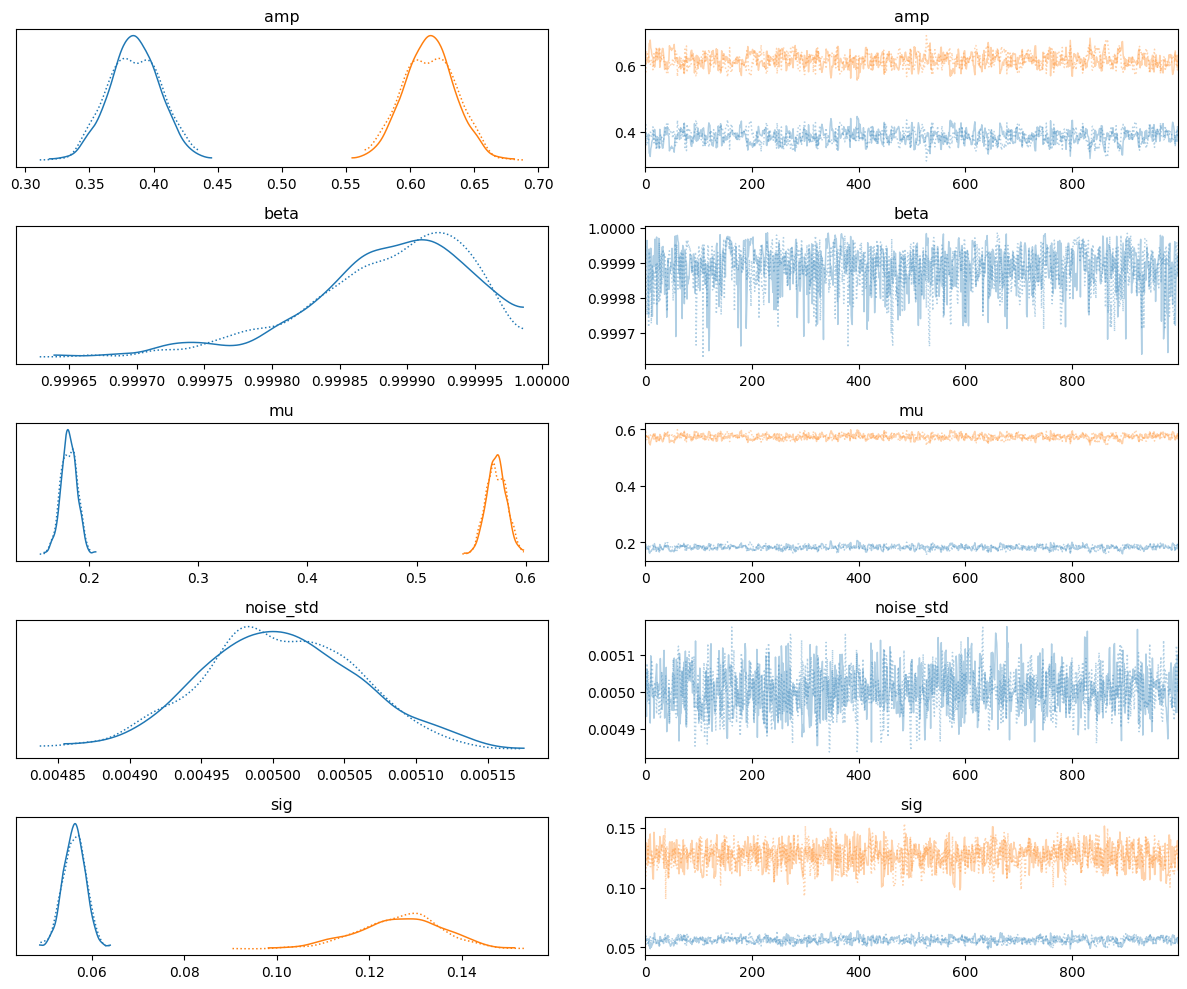

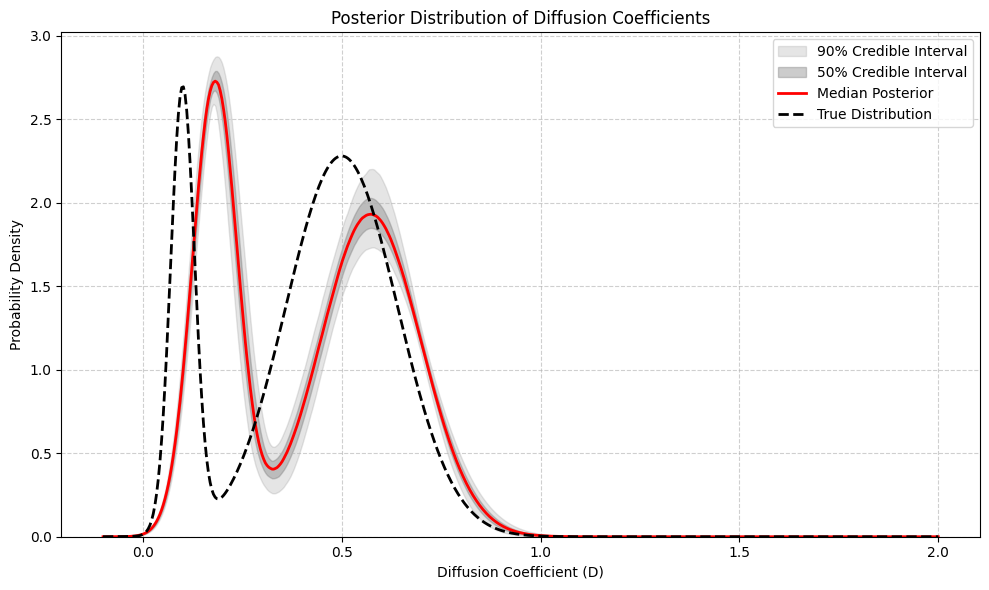

In [38]:
# --- Visualize the results with ArviZ ---
# This is still useful for diagnosing the individual parameters
# print("\nGenerating ArviZ plots...")
idata = az.from_numpyro(mcmc)
az.plot_trace(idata, var_names=["~mu0"])
plt.tight_layout()
plt.show()

# 5. Get posterior samples
posterior_samples = mcmc.get_samples()
amps = posterior_samples['amp']
mus = posterior_samples['mu']
sigs = posterior_samples['sig']
# sigs = true_params['sig']

# 6. Define a helper function for a Gaussian PDF
def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# 7. Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))
D_range = np.linspace(-0.1, 2, 500) # Range of diffusion coefficients

# 8. Calculate all posterior PDFs and store them in a matrix
num_samples = amps.shape[0]
num_components = amps.shape[1]
all_pdfs = np.zeros((num_samples, len(D_range)))

for i in range(num_samples):
    for j in range(num_components):
        all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[i, j])
        # all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[j])
        
# 9. Calculate quantiles to define the credible intervals
# We'll calculate the 90% interval (5th to 95th percentile) and
# the 50% interval (25th to 75th percentile).
q5, q25, q50, q75, q95 = np.quantile(all_pdfs, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)

# 10. Plot the credible interval bands
# The wider, more transparent band (90% CI)
ax.fill_between(D_range, q5, q95, color='gray', alpha=0.2, label='90% Credible Interval')
# The narrower, darker band (50% CI)
ax.fill_between(D_range, q25, q75, color='gray', alpha=0.4, label='50% Credible Interval')

# 11. Plot the median posterior distribution
# The median (50th percentile) is often more robust than the mean.
ax.plot(D_range, q50, color='red', lw=2, label='Median Posterior')

# 12. Plot the true distribution for comparison
true_mixture_pdf = np.zeros_like(D_range)
for j in range(true_params['amp'].shape[0]):
    true_mixture_pdf += true_params['amp'][j] * gaussian(D_range, true_params['mu'][j], true_params['sig'][j])
ax.plot(D_range, true_mixture_pdf, color='black', ls='--', lw=2, label='True Distribution')

# 13. Finalize the plot
ax.set_xlabel('Diffusion Coefficient (D)')
ax.set_ylabel('Probability Density')
ax.set_title('Posterior Distribution of Diffusion Coefficients')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()



In [35]:
mcmc.print_summary()
true_params


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
     amp[0]      0.74      0.01      0.74      0.73      0.75    410.56      1.00
     amp[1]      0.26      0.01      0.26      0.25      0.27    410.56      1.00
       beta      1.00      0.00      1.00      1.00      1.00    864.35      1.00
      mu[0]      0.52      0.00      0.52      0.52      0.53    416.97      1.00
      mu[1]      0.12      0.00      0.12      0.12      0.13    411.16      1.00
  noise_std      0.00      0.00      0.00      0.00      0.00   1187.85      1.00
     sig[0]      0.11      0.01      0.11      0.10      0.12    494.76      1.00
     sig[1]      0.04      0.00      0.04      0.04      0.04    434.24      1.00

Number of divergences: 0


{'beta': 1.0,
 'amp': Array([0.8, 0.2], dtype=float64),
 'mu': Array([0.5, 0.1], dtype=float64),
 'sig': Array([0.14, 0.03], dtype=float64),
 'loss': 0.01,
 'noise_std': 0.001}

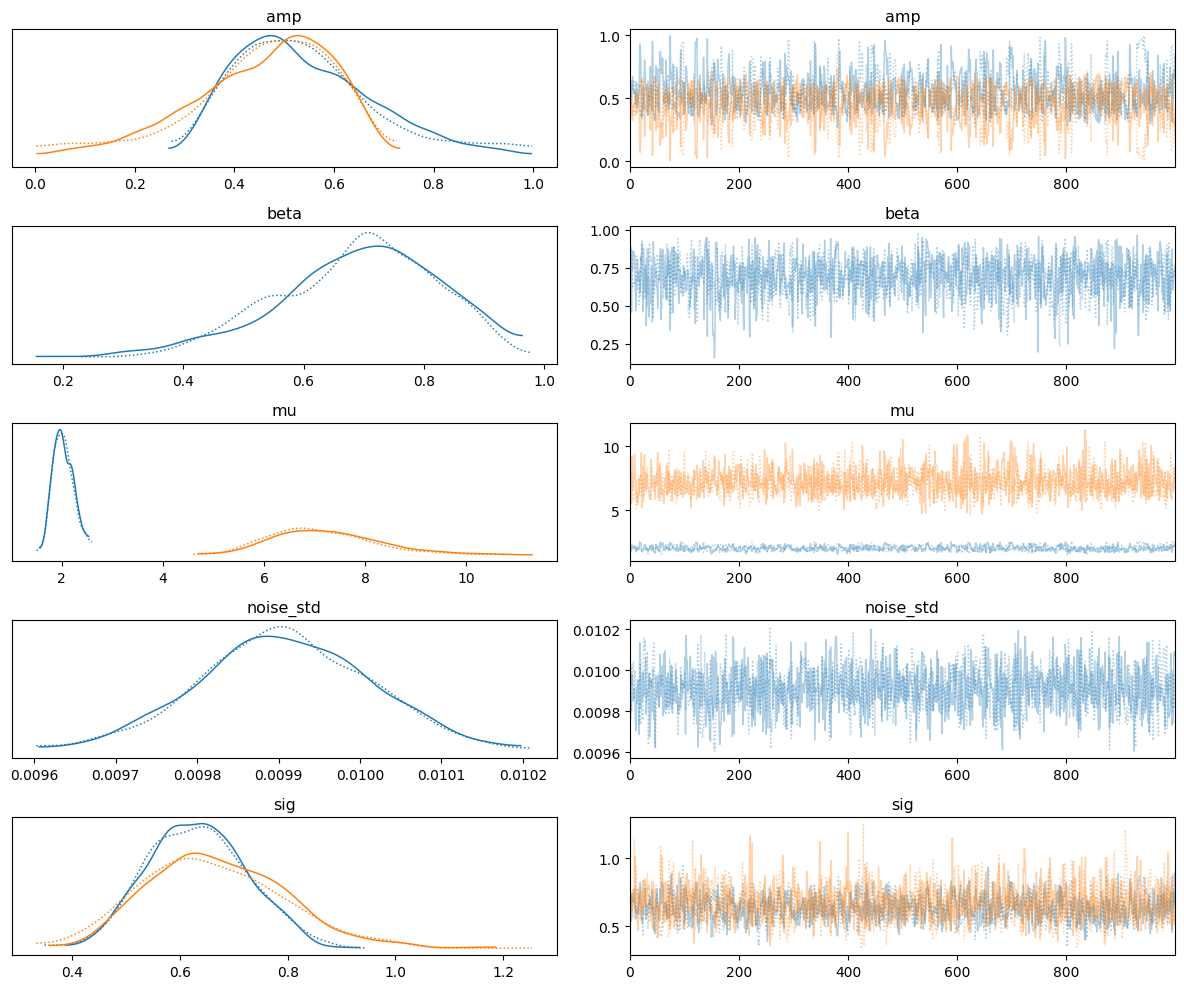

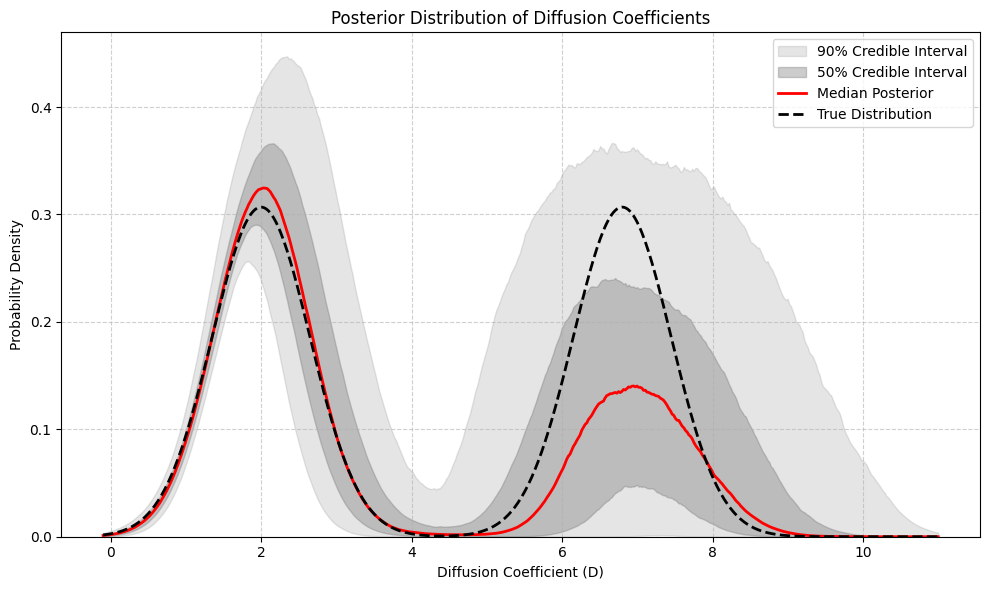

In [15]:
### FREE sigs viz

# --- Visualize the results with ArviZ ---
# This is still useful for diagnosing the individual parameters
# print("\nGenerating ArviZ plots...")
idata = az.from_numpyro(mcmc)
az.plot_trace(idata, var_names=["~mu0", "~mu_inc"])
plt.tight_layout()
plt.show()

# 5. Get posterior samples
posterior_samples = mcmc.get_samples()
amps = posterior_samples['amp']
mus = posterior_samples['mu']
sigs = posterior_samples['sig']
# sigs = true_params['sig']

# 6. Define a helper function for a Gaussian PDF
def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# 7. Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))
D_range = np.linspace(-0.1, 11, 500) # Range of diffusion coefficients

# 8. Calculate all posterior PDFs and store them in a matrix
num_samples = amps.shape[0]
num_components = amps.shape[1]
all_pdfs = np.zeros((num_samples, len(D_range)))

for i in range(num_samples):
    for j in range(num_components):
        all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[i, j])
        # all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[j])
        
# 9. Calculate quantiles to define the credible intervals
# We'll calculate the 90% interval (5th to 95th percentile) and
# the 50% interval (25th to 75th percentile).
q5, q25, q50, q75, q95 = np.quantile(all_pdfs, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)

# 10. Plot the credible interval bands
# The wider, more transparent band (90% CI)
ax.fill_between(D_range, q5, q95, color='gray', alpha=0.2, label='90% Credible Interval')
# The narrower, darker band (50% CI)
ax.fill_between(D_range, q25, q75, color='gray', alpha=0.4, label='50% Credible Interval')

# 11. Plot the median posterior distribution
# The median (50th percentile) is often more robust than the mean.
ax.plot(D_range, q50, color='red', lw=2, label='Median Posterior')

# 12. Plot the true distribution for comparison
true_mixture_pdf = np.zeros_like(D_range)
for j in range(true_params['amp'].shape[0]):
    true_mixture_pdf += true_params['amp'][j] * gaussian(D_range, true_params['mu'][j], true_params['sig'][j])
ax.plot(D_range, true_mixture_pdf, color='black', ls='--', lw=2, label='True Distribution')

# 13. Finalize the plot
ax.set_xlabel('Diffusion Coefficient (D)')
ax.set_ylabel('Probability Density')
ax.set_title('Posterior Distribution of Diffusion Coefficients')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()



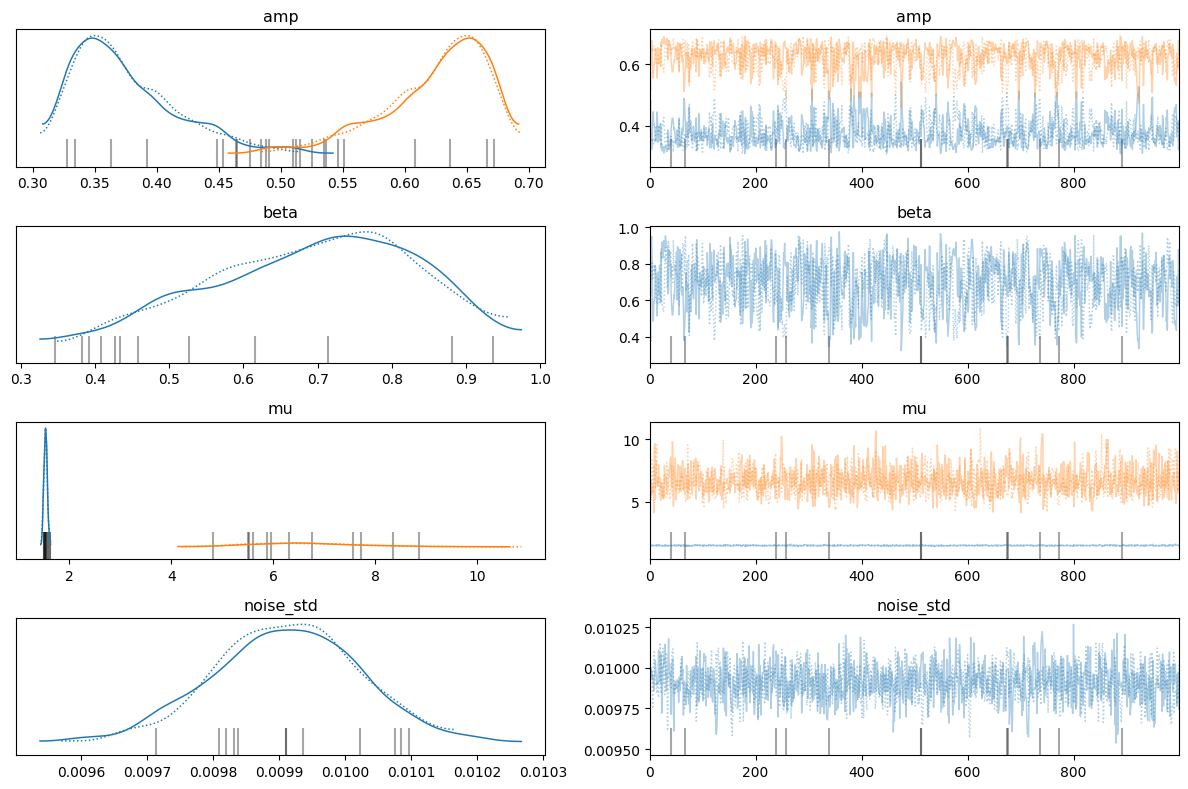

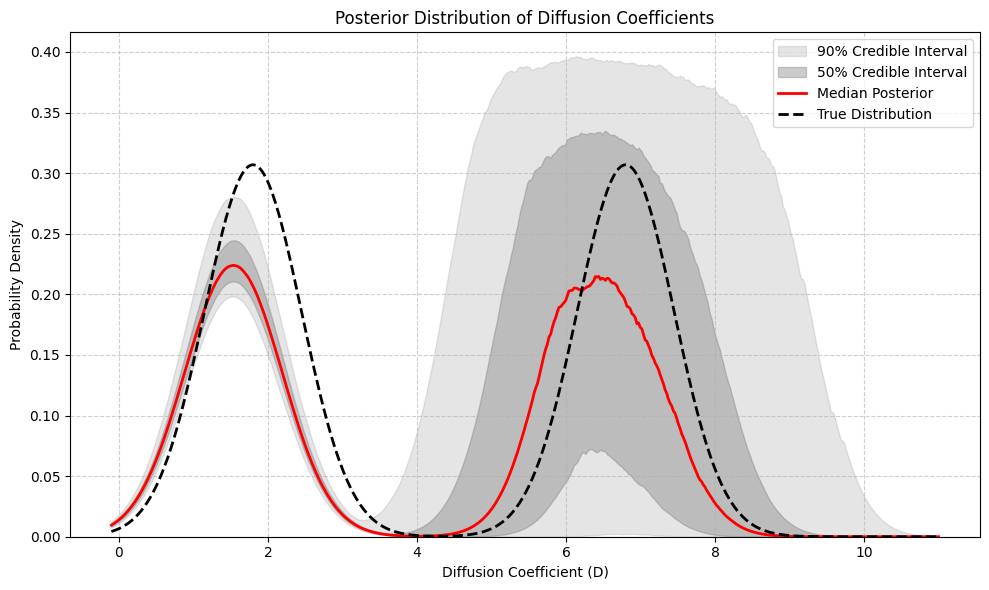

In [ ]:
### FIXED sigs viz


# --- Visualize the results with ArviZ ---
# This is still useful for diagnosing the individual parameters
# print("\nGenerating ArviZ plots...")
idata = az.from_numpyro(mcmc)
az.plot_trace(idata, var_names=["~mu0", "~mu_inc"])
plt.tight_layout()
plt.show()

# 5. Get posterior samples
posterior_samples = mcmc.get_samples()
amps = posterior_samples['amp']
mus = posterior_samples['mu']
sigs = posterior_samples['sig']
# sigs = true_params['sig']

# 6. Define a helper function for a Gaussian PDF
def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# 7. Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))
D_range = np.linspace(-0.1, 11, 500) # Range of diffusion coefficients

# 8. Calculate all posterior PDFs and store them in a matrix
num_samples = amps.shape[0]
num_components = amps.shape[1]
all_pdfs = np.zeros((num_samples, len(D_range)))

for i in range(num_samples):
    for j in range(num_components):
        all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[i, j])
        # all_pdfs[i, :] += amps[i, j] * gaussian(D_range, mus[i, j], sigs[j])
        
# 9. Calculate quantiles to define the credible intervals
# We'll calculate the 90% interval (5th to 95th percentile) and
# the 50% interval (25th to 75th percentile).
q5, q25, q50, q75, q95 = np.quantile(all_pdfs, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)

# 10. Plot the credible interval bands
# The wider, more transparent band (90% CI)
ax.fill_between(D_range, q5, q95, color='gray', alpha=0.2, label='90% Credible Interval')
# The narrower, darker band (50% CI)
ax.fill_between(D_range, q25, q75, color='gray', alpha=0.4, label='50% Credible Interval')

# 11. Plot the median posterior distribution
# The median (50th percentile) is often more robust than the mean.
ax.plot(D_range, q50, color='red', lw=2, label='Median Posterior')

# 12. Plot the true distribution for comparison
true_mixture_pdf = np.zeros_like(D_range)
for j in range(true_params['amp'].shape[0]):
    true_mixture_pdf += true_params['amp'][j] * gaussian(D_range, true_params['mu'][j], true_params['sig'][j])
ax.plot(D_range, true_mixture_pdf, color='black', ls='--', lw=2, label='True Distribution')

# 13. Finalize the plot
ax.set_xlabel('Diffusion Coefficient (D)')
ax.set_ylabel('Probability Density')
ax.set_title('Posterior Distribution of Diffusion Coefficients')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()



In [11]:
true_params

{'beta': 0.7,
 'amp': Array([0.5, 0.5], dtype=float64),
 'mu': Array([1.8, 6.8], dtype=float64),
 'sig': Array([0.65, 0.65], dtype=float64),
 'noise_std': 0.01}